<a href="https://colab.research.google.com/github/beyzaturku/2209/blob/main/yolo_models/yolo5_train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 126.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 98.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 107.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

In [3]:
import torch
from ultralytics import YOLO
import pandas as pd
import matplotlib.pyplot as plt
import cv2

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [8]:
def train_yolo():
    model = YOLO('yolov5nu.pt')

    results = model.train(
        data='/content/drive/MyDrive/altitude/high_alt_object_detection/dataset/data.yaml',
        epochs=50,
        imgsz=640,
        batch=16,
        project="/content/drive/MyDrive/altitude/high_alt_object_detection/yolo5_train",
        name="yolov5",
        save=True,
        save_period=5,
        val=True
    )
    return model, results

In [16]:
def create_metrics_table(csv_path):
    # CSV dosyasını oku
    df = pd.read_csv(csv_path)

    # Önemli sütunları seç ve yeniden adlandır
    metrics_df = df[['epoch', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
                     'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
                     'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss']].copy()

    # Sütun isimlerini sadeleştir
    metrics_df.columns = ['Epoch', 'Train_Box_Loss', 'Train_Cls_Loss', 'Train_DFL_Loss',
                         'Precision', 'Recall', 'mAP50', 'mAP50_95',
                         'Val_Box_Loss', 'Val_Cls_Loss', 'Val_DFL_Loss']

    print("Model Performans Metrikleri:")
    print(metrics_df.tail(10))  # Son 10 epoch
    return metrics_df

def visualize_results(df):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Loss grafikleri (Train vs Val)
    axes[0,0].plot(df['Epoch'], df['Train_Box_Loss'], label='Train Box Loss', color='blue')
    axes[0,0].plot(df['Epoch'], df['Val_Box_Loss'], label='Val Box Loss', color='red')
    axes[0,0].set_title('Box Loss Eğrileri')
    axes[0,0].set_xlabel('Epoch')
    axes[0,0].set_ylabel('Loss')
    axes[0,0].legend()
    axes[0,0].grid(True)

    # mAP grafikleri
    axes[0,1].plot(df['Epoch'], df['mAP50'], label='mAP50', color='green')
    axes[0,1].plot(df['Epoch'], df['mAP50_95'], label='mAP50-95', color='orange')
    axes[0,1].set_title('mAP Metrikleri')
    axes[0,1].set_xlabel('Epoch')
    axes[0,1].set_ylabel('mAP')
    axes[0,1].legend()
    axes[0,1].grid(True)

    # Precision ve Recall
    axes[1,0].plot(df['Epoch'], df['Precision'], label='Precision', color='purple')
    axes[1,0].plot(df['Epoch'], df['Recall'], label='Recall', color='brown')
    axes[1,0].set_title('Precision & Recall')
    axes[1,0].set_xlabel('Epoch')
    axes[1,0].set_ylabel('Değer')
    axes[1,0].legend()
    axes[1,0].grid(True)

    # Tüm Loss türleri
    axes[1,1].plot(df['Epoch'], df['Train_Box_Loss'], label='Box Loss')
    axes[1,1].plot(df['Epoch'], df['Train_Cls_Loss'], label='Cls Loss')
    axes[1,1].plot(df['Epoch'], df['Train_DFL_Loss'], label='DFL Loss')
    axes[1,1].set_title('Eğitim Loss Türleri')
    axes[1,1].set_xlabel('Epoch')
    axes[1,1].set_ylabel('Loss')
    axes[1,1].legend()
    axes[1,1].grid(True)

    plt.tight_layout()
    plt.show()

    # Son epoch özet tablosu
    final_metrics = df.iloc[-1]
    print(f"\nFinal Epoch ({int(final_metrics['Epoch'])}) Sonuçları:")
    print(f"mAP50: {final_metrics['mAP50']:.4f}")
    print(f"mAP50-95: {final_metrics['mAP50_95']:.4f}")
    print(f"Precision: {final_metrics['Precision']:.4f}")
    print(f"Recall: {final_metrics['Recall']:.4f}")

def test_single_image(model_path, image_path, conf_threshold=0.25, iou_threshold=0.45):
    model = YOLO(model_path)

    # Düşük threshold ile tahmin (daha fazla tespit için)
    results = model(image_path, conf=conf_threshold, iou=iou_threshold)

    # Görselleştirme
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Sonuçları çiz
    annotated_img = results[0].plot()

    plt.figure(figsize=(12, 8))
    plt.imshow(annotated_img)
    plt.title(f'YOLO Tespiti (conf≥{conf_threshold}, iou≥{iou_threshold}) - {len(results[0].boxes) if results[0].boxes is not None else 0} nesne bulundu')
    plt.axis('off')
    plt.show()

    # Detay bilgiler
    if results[0].boxes is not None:
        print(f"\nToplam {len(results[0].boxes)} nesne tespit edildi:")
        print("-" * 40)
        for i, box in enumerate(results[0].boxes):
            conf = box.conf.item()
            cls = int(box.cls.item())
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            print(f"Nesne {i+1}: Sınıf {cls}, Güven: {conf:.3f}, Box: [{x1:.0f},{y1:.0f},{x2:.0f},{y2:.0f}]")
    else:
        print("Hiç nesne tespit edilmedi!")

    return results

def compare_thresholds(model_path, image_path):
    """Farklı confidence ve IOU threshold'larını karşılaştır"""
    thresholds = [
        (0.5, 0.5),   # Varsayılan (yüksek)
        (0.3, 0.4),   # Orta
        (0.1, 0.3)    # Düşük (daha hassas)
    ]

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for i, (conf, iou) in enumerate(thresholds):
        model = YOLO(model_path)
        results = model(image_path, conf=conf, iou=iou)

        annotated_img = results[0].plot()

        axes[i].imshow(annotated_img)
        axes[i].set_title(f'conf={conf}, iou={iou}\n{len(results[0].boxes) if results[0].boxes is not None else 0} tespit')
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

In [12]:
import torch
from ultralytics import YOLO
import pandas as pd
import matplotlib.pyplot as plt
import cv2

print("1. Model eğitimi başlatılıyor...")
model, results = train_yolo()

1. Model eğitimi başlatılıyor...


100%|██████████| 5.31M/5.31M [00:00<00:00, 67.0MB/s]


Ultralytics 8.3.156 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/altitude/high_alt_object_detection/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov5nu.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov5, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pa

100%|██████████| 5.35M/5.35M [00:00<00:00, 67.0MB/s]


AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.3±0.1 ms, read: 42.7±17.3 MB/s, size: 49.0 KB)


...

      50/50       2.3G      1.019     0.6161     0.8028        115        640: 100%|██████████| 18/18 [00:01<00:00, 10.02it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:00<00:00,  8.16it/s]

                   all         71        925      0.963      0.948      0.976      0.796



50 epochs completed in 0.036 hours.
Optimizer stripped from /content/drive/MyDrive/altitude/high_alt_object_detection/yolo5_train/yolov5/weights/last.pt, 5.2MB
Optimizer stripped from /content/drive/MyDrive/altitude/high_alt_object_detection/yolo5_train/yolov5/weights/best.pt, 5.2MB

Validating /content/drive/MyDrive/altitude/high_alt_object_detection/yolo5_train/yolov5/weights/best.pt...
Ultralytics 8.3.156 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
YOLOv5n summary (fused): 84 layers, 2,503,724 parameters, 0 gradients, 7.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:00<00:00,  3.94it/s]


                   all         71        925      0.961      0.945      0.975      0.798
                   car         71        912      0.923       0.93      0.954       0.65
                   bus         13         13          1      0.961      0.995      0.945
Speed: 0.1ms preprocess, 0.5ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to /content/drive/MyDrive/altitude/high_alt_object_detection/yolo5_train/yolov5



2. CSV'den metrikler okunuyor...
Model Performans Metrikleri:
    Epoch  Train_Box_Loss  Train_Cls_Loss  Train_DFL_Loss  Precision   Recall  \
40     41         1.19640         0.72103         0.81168    0.97422  0.93096   
41     42         1.12031         0.67672         0.81401    0.96831  0.90374   
42     43         1.09860         0.66177         0.80640    0.95381  0.95118   
43     44         1.08157         0.65055         0.80352    0.97142  0.95027   
44     45         1.06436         0.63917         0.81141    0.97025  0.94641   
45     46         1.05153         0.63332         0.81049    0.95866  0.94455   
46     47         1.08281         0.63795         0.81359    0.96814  0.91950   
47     48         1.02585         0.61575         0.80435    0.96766  0.91629   
48     49         1.03184         0.62120         0.80266    0.96139  0.94482   
49     50         1.01875         0.61605         0.80283    0.96315  0.94792   

      mAP50  mAP50_95  Val_Box_Loss  Val_Cls_

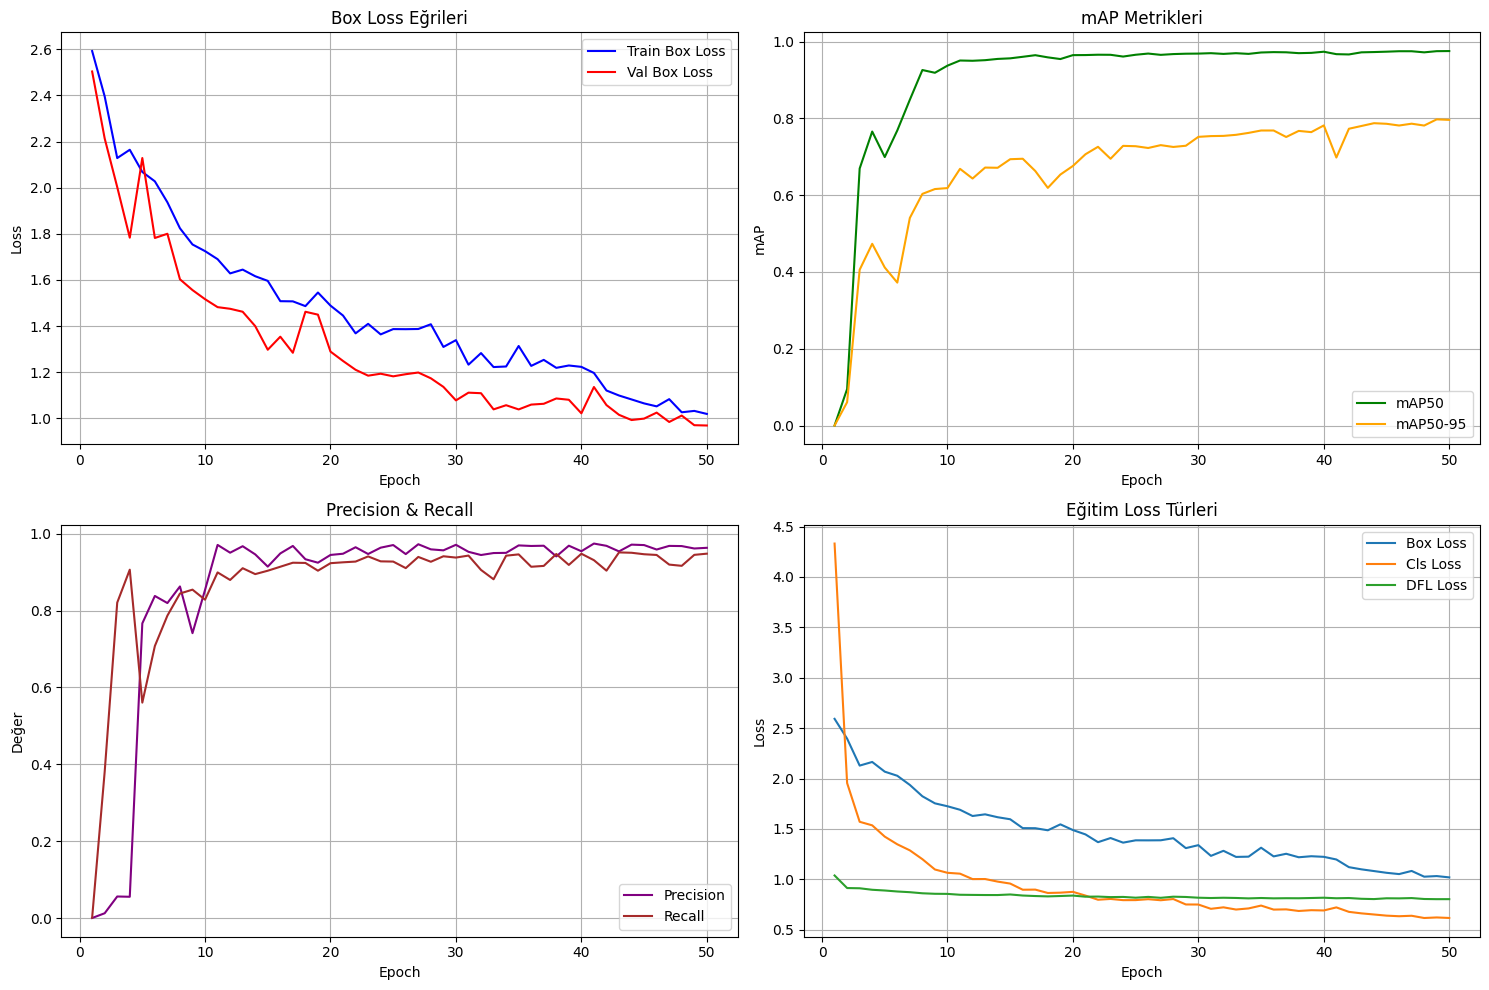


Final Epoch (50) Sonuçları:
mAP50: 0.9756
mAP50-95: 0.7963
Precision: 0.9631
Recall: 0.9479

4. Tek görsel test ediliyor...

image 1/1 /content/drive/MyDrive/altitude/high_alt_object_detection/test_dataset/high_alt_images/M0701_img000377.jpg: 352x640 7 cars, 2 buss, 10.3ms
Speed: 2.1ms preprocess, 10.3ms inference, 2.0ms postprocess per image at shape (1, 3, 352, 640)


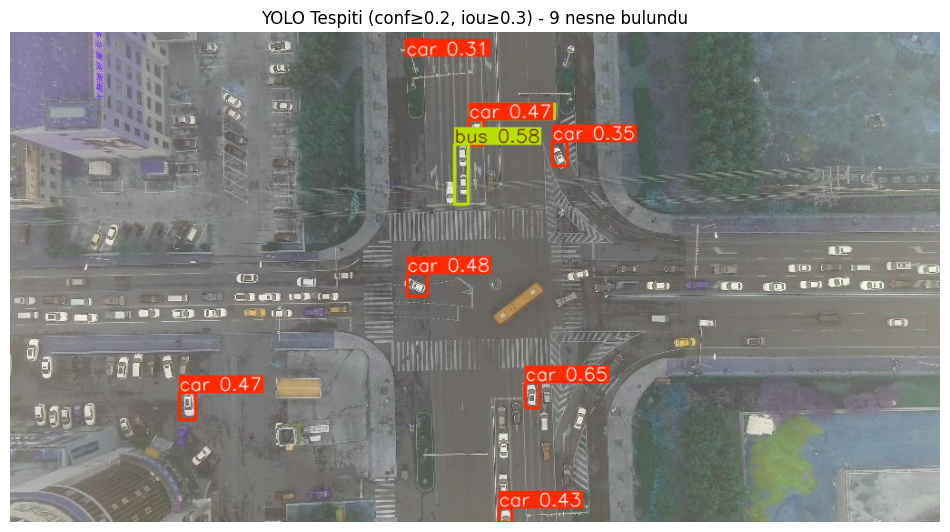


Toplam 9 nesne tespit edildi:
----------------------------------------
Nesne 1: Sınıf 0, Güven: 0.646, Box: [567,386,583,414]
Nesne 2: Sınıf 3, Güven: 0.585, Box: [489,124,505,190]
Nesne 3: Sınıf 0, Güven: 0.480, Box: [438,266,460,291]
Nesne 4: Sınıf 0, Güven: 0.472, Box: [506,98,521,126]
Nesne 5: Sınıf 0, Güven: 0.469, Box: [187,398,205,428]
Nesne 6: Sınıf 0, Güven: 0.426, Box: [539,524,553,540]
Nesne 7: Sınıf 0, Güven: 0.349, Box: [598,122,614,149]
Nesne 8: Sınıf 0, Güven: 0.311, Box: [437,9,459,27]
Nesne 9: Sınıf 3, Güven: 0.200, Box: [505,98,521,126]

4. Farklı threshold'lar karşılaştırılıyor...

image 1/1 /content/drive/MyDrive/altitude/high_alt_object_detection/test_dataset/high_alt_images/M0701_img000377.jpg: 352x640 1 car, 1 bus, 9.4ms
Speed: 2.0ms preprocess, 9.4ms inference, 1.6ms postprocess per image at shape (1, 3, 352, 640)

image 1/1 /content/drive/MyDrive/altitude/high_alt_object_detection/test_dataset/high_alt_images/M0701_img000377.jpg: 352x640 7 cars, 1 bus, 9.7ms
S

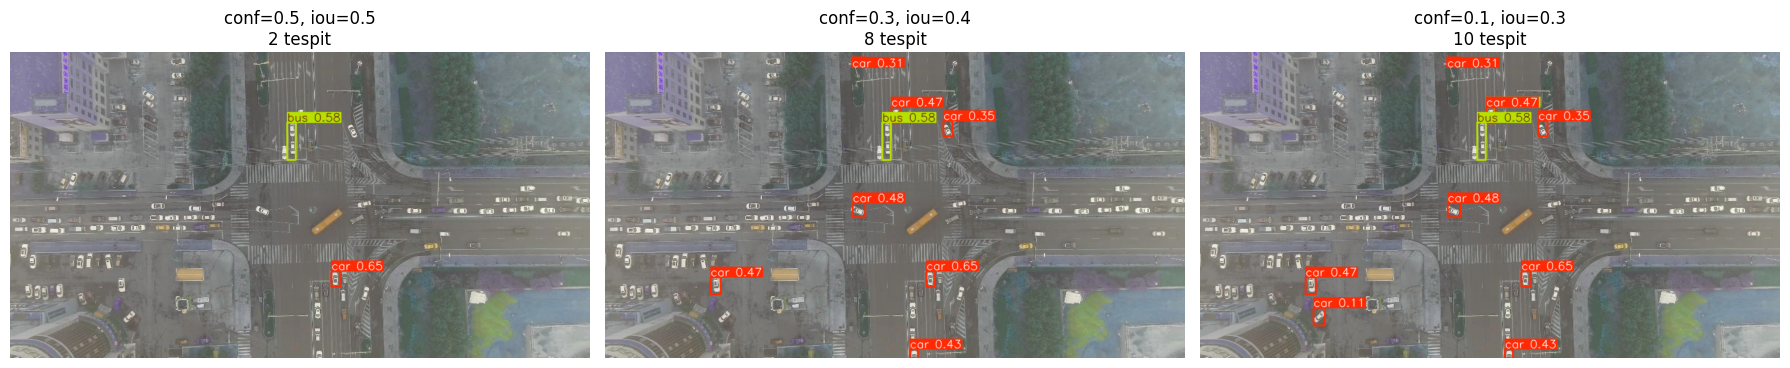

In [17]:
print("\n2. CSV'den metrikler okunuyor...")
df = create_metrics_table('/content/drive/MyDrive/altitude/high_alt_object_detection/yolo5_train/yolov5/results.csv')

    # Görselleştir
print("\n3. Sonuçlar görselleştiriliyor...")
visualize_results(df)

    # Test et
print("\n4. Tek görsel test ediliyor...")
test_single_image('/content/drive/MyDrive/altitude/high_alt_object_detection/yolo5_train/yolov5/weights/best.pt', '/content/drive/MyDrive/altitude/high_alt_object_detection/test_dataset/high_alt_images/M0701_img000377.jpg', conf_threshold=0.2, iou_threshold=0.3)

print("\n4. Farklı threshold'lar karşılaştırılıyor...")
compare_thresholds('/content/drive/MyDrive/altitude/high_alt_object_detection/yolo5_train/yolov5/weights/best.pt', '/content/drive/MyDrive/altitude/high_alt_object_detection/test_dataset/high_alt_images/M0701_img000377.jpg')


image 1/1 /content/drive/MyDrive/altitude/high_alt_object_detection/test_dataset/high_alt_images/M0701_img000377.jpg: 352x640 8 cars, 2 buss, 9.8ms
Speed: 2.0ms preprocess, 9.8ms inference, 1.6ms postprocess per image at shape (1, 3, 352, 640)


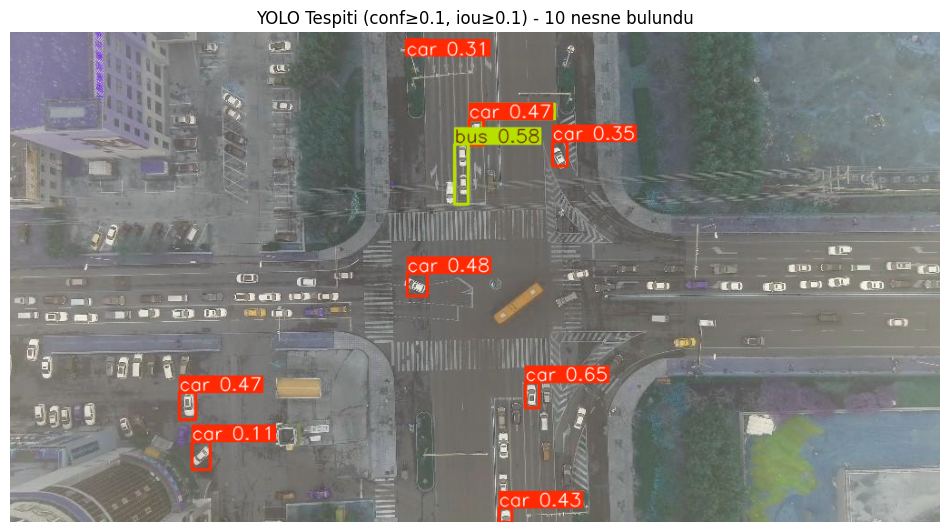


Toplam 10 nesne tespit edildi:
----------------------------------------
Nesne 1: Sınıf 0, Güven: 0.646, Box: [567,386,583,414]
Nesne 2: Sınıf 3, Güven: 0.585, Box: [489,124,505,190]
Nesne 3: Sınıf 0, Güven: 0.480, Box: [438,266,460,291]
Nesne 4: Sınıf 0, Güven: 0.472, Box: [506,98,521,126]
Nesne 5: Sınıf 0, Güven: 0.469, Box: [187,398,205,428]
Nesne 6: Sınıf 0, Güven: 0.426, Box: [539,524,553,540]
Nesne 7: Sınıf 0, Güven: 0.349, Box: [598,122,614,149]
Nesne 8: Sınıf 0, Güven: 0.311, Box: [437,9,459,27]
Nesne 9: Sınıf 3, Güven: 0.200, Box: [505,98,521,126]
Nesne 10: Sınıf 0, Güven: 0.107, Box: [200,452,220,483]


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'car', 1: 'vehicle', 2: 'truck', 3: 'bus'}
 obb: None
 orig_img: array([[[130, 124, 155],
         [130, 124, 155],
         [131, 125, 156],
         ...,
         [130, 146, 158],
         [136, 152, 164],
         [142, 158, 170]],
 
        [[133, 127, 158],
         [133, 127, 158],
         [133, 127, 158],
         ...,
         [132, 148, 160],
         [136, 152, 164],
         [139, 155, 167]],
 
        [[136, 130, 161],
         [136, 130, 161],
         [135, 129, 160],
         ...,
         [134, 150, 162],
         [135, 151, 163],
         [136, 152, 164]],
 
        ...,
 
        [[139, 136, 131],
         [137, 134, 129],
         [134, 131, 126],
         ...,
         [134, 139, 130],
         [133, 138, 129],
         [133, 138, 129]],
 
        [[139, 136, 132],
         [136, 133, 129],
         [132, 129, 125],

In [18]:
test_single_image('/content/drive/MyDrive/altitude/high_alt_object_detection/yolo5_train/yolov5/weights/best.pt', '/content/drive/MyDrive/altitude/high_alt_object_detection/test_dataset/high_alt_images/M0701_img000377.jpg', conf_threshold=0.1, iou_threshold=0.1)